# Deconvolution

### Imports


In [158]:
import matplotlib.pyplot as plt
import numpy as np
import s3fs
import zarr

from deep_neurographs import img_utils
from copy import deepcopy
from scipy.ndimage import center_of_mass
from skimage import restoration
from tifffile import imread, imwrite
from time import time

%matplotlib inline

IMG_PREFIX = {
    "685221": "exaSPIM_685221_2024-04-12_11-46-38_fusion_2024-07-22_21-00-15",
    "703070": "exaSPIM_703070_2024-07-09_12-52-33_flatfield-correction_2024-07-18_12-43-27_fusion_2024-08-02_17-11-59",
    "706301": "exaSPIM_706301_2024-04-23_11-24-24_fusion_2024-05-21_00-00-03",
    "708369": "exaSPIM_708369_2024-04-08_15-20-36_fusion_2024-05-20_23-30-43",
    "709393": "exaSPIM_709393_2024-04-17_09-37-51_fusion_2024-07-27_00-20-20",
    "715345": "exaSPIM_715345_2024-06-07_10-03-37_fusion_2024-07-02_10-30-40"
}

In [208]:
# Subroutines
def rescale(arr, clip=True):
    if clip:
        arr = np.clip(arr, 0, np.percentile(arr, 99))
    arr -= np.min(arr)
    arr = (2**16 - 1) * (arr / np.max(arr))
    return (arr).astype(np.uint16)


def get_mip(arr, axis=0, clip=False):
    mip = np.max(arr, axis=axis)
    mip = rescale(mip, clip=clip)
    return mip


def read_from_s3(img, voxel, shape, from_center=True):
    start, end = img_utils.get_start_end(voxel, shape, from_center=from_center)
    return img[0, 0, start[2]:end[2], start[1]:end[1], start[0]:end[0]]


def plot_mips(volume, prefix="", clip=True):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs_names = ["XY", "XZ", "YZ"]
    for i in range(3):
        axs[i].imshow(get_mip(volume, axis=i, clip=clip))
        axs[i].set_title(prefix + axs_names[i], fontsize=16)
        axs[i].set_xticks([])
        axs[i].set_yticks([])
    plt.tight_layout()
    plt.show()


### Opem img

In [188]:
# Parameters
s3_bucket = "aind-open-data"
dataset = "685221"
downsample_factor = 1

# Initializations
fs = s3fs.S3FileSystem()
s3_url = f"s3://{s3_bucket}/{IMG_PREFIX[dataset]}/fused.zarr/{downsample_factor}/"

# Open img
store = s3fs.S3Map(root=s3_url, s3=fs)
img = zarr.open(store, mode='r')


### Read img

In [42]:
# 706301
sites = [
    [30586, 14624, 6969],
    [17905, 11089, 2404],
    [20448, 8114, 11599],
    [36810, 9475, 19464],
    [40461, 5576, 18250],
]

# 715345
sites = [
    [14519.661, 6689.612, 7078.8433],
    #[14925.678,7363.8457,6410.833],
    #[15023.707,7896.712,5052.8823]
]

# 703070
sites = [
    [29165.006,9058.395,16358.04],
    [28144.078,9013.699,16256.166],
    [38457.11,7004.009,9491.203]
]

# 685221
sites = [
    [36192.61,4550.172,17781.904],
    [15607.308,7482.335,10778.958],
    [11889.736,7266.553,9161.477],
]

# 709393
sites = [
    [6676.8022,11603.722,9432.193]
]

# Doubling in x,y,z
# [36063.15,9586.425,20097.422]

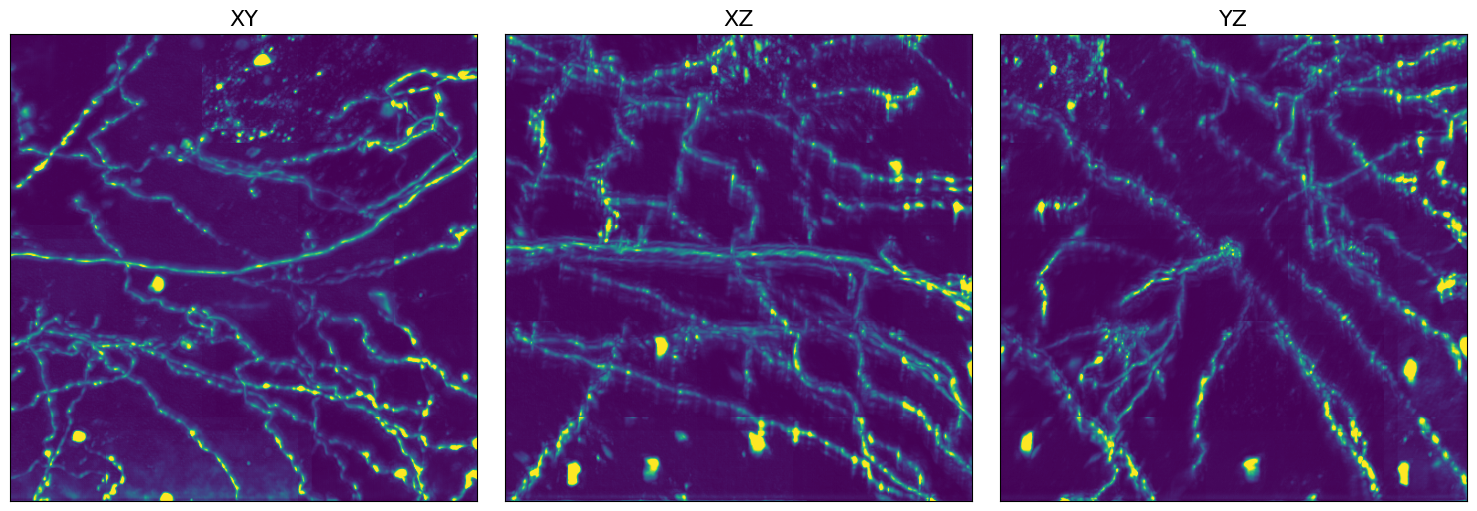

In [210]:
# Region of interest
origin = [36192.61,4550.172,17781.904]
shape = [512, 512, 512]
from_center = True

# Read img
voxel = img_utils.to_voxels(origin, downsample_factor=downsample_factor)
#img_chunk = read_from_s3(img, voxel, shape, from_center=from_center)
img_chunk = imread("/root/capsule/results/inference/exaspim_685221_by_20240910-0045_axial_to_lateral_gan_apollo/test_latest_iter14000/volumes/output_volume_xy-view_iter-14000.tif")
img_chunk = rescale(img_chunk, clip=False)
#imwrite(f"/root/capsule/data/exaspim_{dataset}/raw.tiff", img_chunk)

# Plot mips
plot_mips(img_chunk, clip=True)


In [6]:
# Save mips
from PIL import Image


# Compute mips
mip_xz = get_mip(img_chunk, axis=1).astype(np.uint8)
mip_yz = get_mip(img_chunk, axis=2).astype(np.uint8)

# Save mips
#Image.fromarray(mip_xz).save('xz.png')
#Image.fromarray(mip_yz).save('yz.png')


### PSF Routines

[1.25, 1.25, 1.25] [0, 0, 0]
[1.5, 1.25, 1.25] [-12, 0, 0]


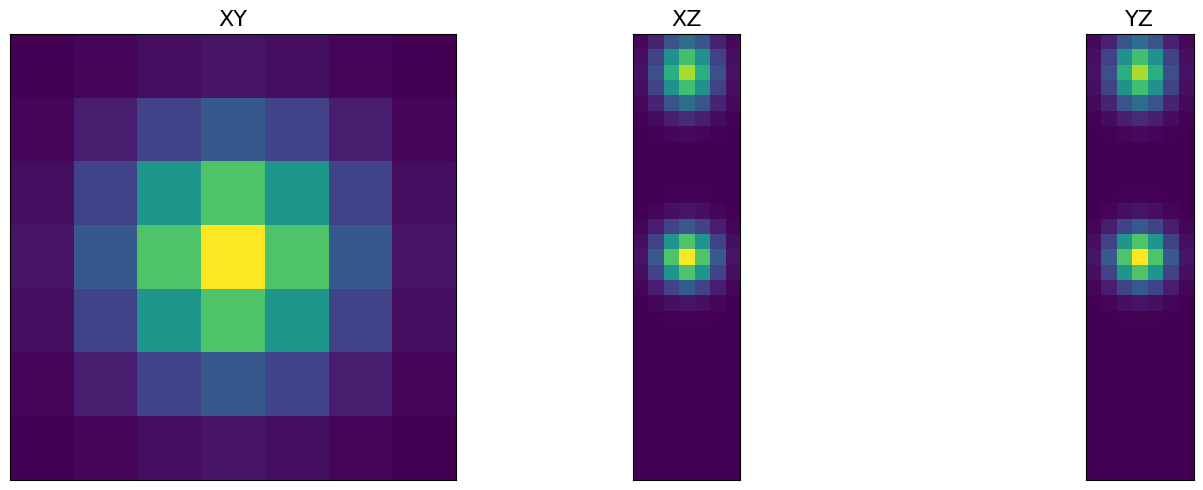

In [90]:
def gaussian_3d(shape, sigma, mu=[0, 0, 0]):
    x, y, z = get_coords_3d(shape)
    gaussian = (1 / (2 * np.pi * np.prod(sigma))) * \
          np.exp(- ((x - mu[0]) ** 2 / (2 * sigma[0] ** 2) +
                    (y - mu[1]) ** 2 / (2 * sigma[1] ** 2) +
                    (z - mu[2]) ** 2 / (2 * sigma[2] ** 2)))
    return gaussian / gaussian.sum()


def gaussian_peaks_3d(shape, amplitudes, sigmas, mus):
    gaussian = np.zeros(shape)
    for i in range(len(sigmas)):
        print(sigmas[i], mus[i])
        gaussian += amplitudes[i] * gaussian_3d(shape, sigmas[i], mu=mus[i])
    return gaussian


def get_coords_3d(shape):
    """
    Generates 3D coordinate grids for a given shape.

    Parameters
    ----------
    shape : Tuple/List
        Shape of the output grids.

    Returns
    -------
    tuple
        xyz coordinates.

    """
    xyz = np.indices(shape)
    for i in range(3):
        xyz[i] -= shape[i] // 2
    return xyz


def estimate_gaussian_stds(img):
    x, y = np.indices(img.shape)
    mu_x, mu_y = center_of_mass(img)
    var_x = np.sum(img * (x - mu_x)**2) / np.sum(img)
    var_y = np.sum(img * (y - mu_y)**2) / np.sum(img)
    return np.sqrt(var_x), np.sqrt(var_y)


# Initialize gaussian kernel
shape = (29, 7, 7)
sigma = [5, 1.6, 1.6]
psf_kernel = gaussian_3d(shape, sigma)

# Initialize gaussian peaks kernel
amplitudes = [2.0, 2.0, 2.0]
sigmas = [
    [1.25, 1.25, 1.25],
    [1.5, 1.25, 1.25],
    #[2, 1.25, 1.25]
]
mus = [
    [0, 0, 0],
    [-12, 0, 0],
    [-6, 0, 0]
]
psf_peaks_kernel = gaussian_peaks_3d(shape, amplitudes, sigmas, mus)
#psf_peaks_kernel[0:10, :, :] = 0

# Visualize Kernel
#plot_mips(psf_kernel, clip=False)
plot_mips(psf_peaks_kernel, clip=False)


## Generate Image Artifacts

In [8]:
from scipy.ndimage import convolve

import torch
import torch.nn as nn


class Conv3D(nn.Module):
    
    def __init__(self, kernel):
        super(Conv3D, self).__init__()
        kernel = np.expand_dims(kernel, axis=(0, 1))
        self.conv3d = nn.Conv3d(
            in_channels=1,
            out_channels=1,
            kernel_size=kernel.shape[2:],
            stride=1,
            padding=0,
        )
        self.conv3d.weight.data = torch.tensor(kernel, dtype=torch.float32)
        self.conv3d.bias.data.zero_()

    def forward(self, x):
        return self.conv3d(x)


# pytorch convolution
t0 = time()
convolve_3d = Conv3D(psf_peaks_kernel).to("cuda")

input_tensor = torch.tensor(np.expand_dims(img_chunk, axis=(0, 1)), dtype=torch.float32).to("cuda")
convolved_img_chunk = convolve_3d(input_tensor).detach().cpu()
convolved_img_chunk = np.array(convolved_img_chunk[0, 0, ...])
print(f"Convolution Runtime: {time() - t0} seconds")

# Visualize Results
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axes_name = ["XY", "XZ", "YZ"]
for i in range(3):
    axs[0, i].imshow(get_mip(img_chunk, axis=i))
    axs[0, i].set_title("Before - " + axes_name[i], fontsize=14)
    axs[0, i].set_xticks([])
    axs[0, i].set_yticks([])

    axs[1, i].imshow(get_mip(convolved_img_chunk, axis=i))
    axs[1, i].set_title("After - " + axes_name[i], fontsize=14)
    axs[1, i].set_xticks([])
    axs[1, i].set_yticks([])
plt.tight_layout()

TypeError: can't convert np.ndarray of type numpy.uint16. The only supported types are: float64, float32, float16, complex64, complex128, int64, int32, int16, int8, uint8, and bool.

## Richardson-Lucy Deconvolution

RL Runtime: 60.33528447151184 seconds


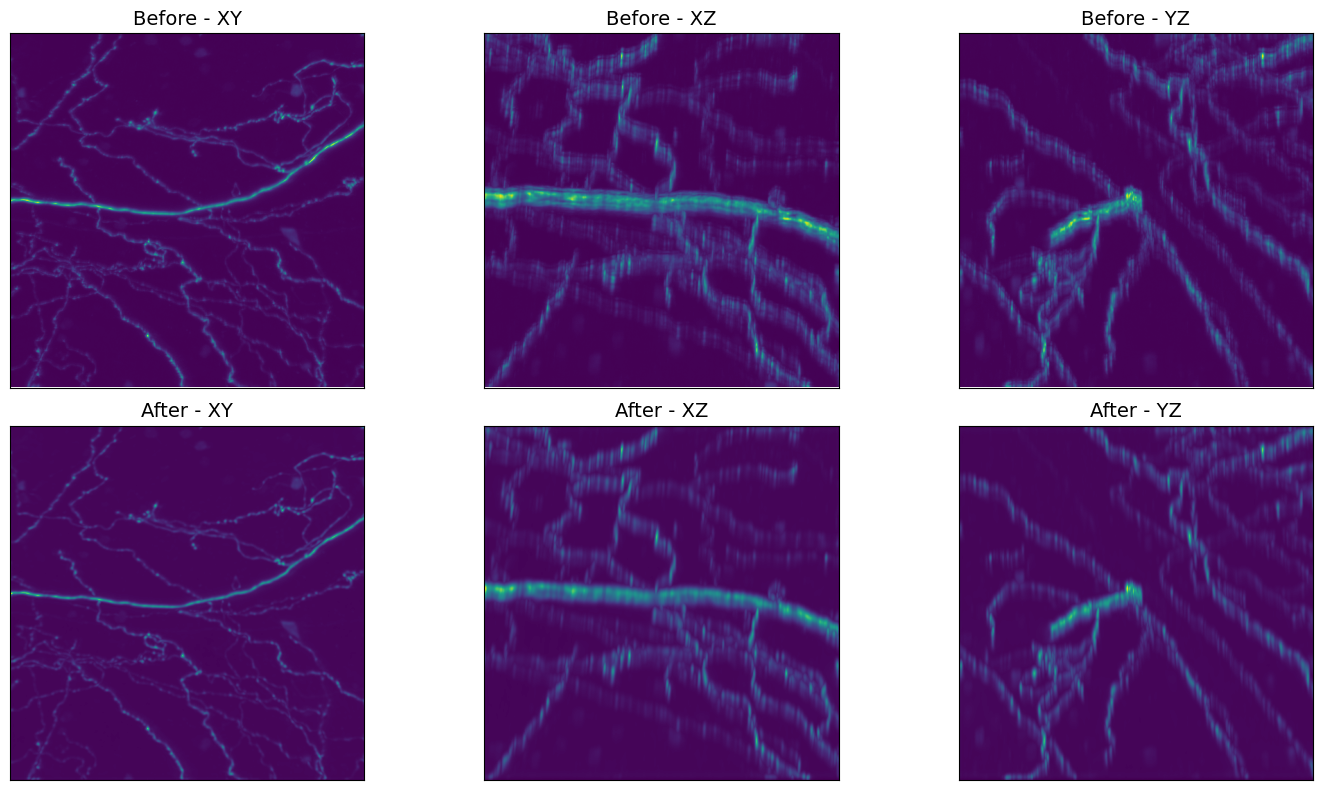

In [93]:
# Main
t0 = time()
num_iter = 5
rl_result = restoration.richardson_lucy(img_chunk, psf_kernel, num_iter, False)
print(f"RL Runtime: {time() - t0} seconds")

# Visualize Resultss
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axes_name = ["XY", "XZ", "YZ"]
for i in range(3):
    axs[0, i].imshow(get_mip(img_chunk, axis=i))
    axs[0, i].set_title("Before - " + axes_name[i], fontsize=14)
    axs[0, i].set_xticks([])
    axs[0, i].set_yticks([])

    axs[1, i].imshow(get_mip(rl_result, axis=i))
    axs[1, i].set_title("After - " + axes_name[i], fontsize=14)
    axs[1, i].set_xticks([])
    axs[1, i].set_yticks([])
plt.tight_layout()
plt.show()


## Wiener Deconvolution

In [ ]:
# Main
t0 = time()
wiener_result = restoration.wiener(convolved_img_chunk, psf_peaks_kernel, 3, clip=False)
wiener_result = np.clip(wiener_result, 0, np.inf)
print(f"RL Runtime: {time() - t0} seconds")

# Visualize Results
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axes_name = ["XY", "XZ", "YZ"]
for i in range(3):
    axs[0, i].imshow(get_mip(convolved_img_chunk, axis=i))
    axs[0, i].set_title("Before - " + axes_name[i], fontsize=14)
    axs[0, i].set_xticks([])
    axs[0, i].set_yticks([])

    axs[1, i].imshow(get_mip(wiener_result, axis=i))
    axs[1, i].set_title("After - " + axes_name[i], fontsize=14)
    axs[1, i].set_xticks([])
    axs[1, i].set_yticks([])
plt.tight_layout()
plt.show()


plt.tight_layout()
plt.show()
imwrite("before.tif", img_chunk)
imwrite("wiener_result.tif", wiener_result - 15)

In [ ]:
print(np.mean(img_chunk), np.mean(wiener_result))
print(np.min(img_chunk), np.min(wiener_result))
print(np.max(img_chunk), np.max(wiener_result))